In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data-treatment.csv')

In [3]:
df.head()

,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,...,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,dia,mes
0,13/08/2007,Segunda,14:25:00,MG,40,585.5,ITABIRITO,Outras,Saída de Pista,Com Vítimas Feridas,...,3,0,0,1,2,0,1,1,13,8
1,12/02/2007,Segunda,02:10:00,MA,135,11.0,SAO LUIS,Animais na Pista,Atropelamento de animal,Com Vítimas Fatais,...,5,2,2,1,0,0,3,1,12,2
2,20/11/2007,Terça,05:30:00,CE,222,30.8,CAUCAIA,Defeito mecânico em veículo,Capotamento,Com Vítimas Feridas,...,1,0,1,0,0,0,1,1,20,11
3,16/12/2007,Domingo,17:40:00,MA,230,14.0,BARAO DE GRAJAU,Outras,Capotamento,Com Vítimas Feridas,...,1,0,0,1,0,0,1,1,16,12
4,05/03/2007,Segunda,08:10:00,PR,277,584.4,CASCAVEL,Outras,Colisão lateral,Sem Vítimas,...,2,0,0,0,2,0,0,2,5,3


In [4]:
df['fase_dia'].unique()

<ArrowStringArray>
['Pleno dia', 'Plena noite', 'Amanhecer', 'Anoitecer']
Length: 4, dtype: str

In [5]:
df['br'] = df['br'].astype(str)
df['km'] = df['km'].astype(str)
df['ano'] = df['ano'].astype(str)


In [6]:
df.describe().round(2)

,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,dia,mes
count,1562033.00,1562033.00,1562033.00,1562033.00,1562033.00,1562033.00,1562033.00,1562033.00,1562033.00,1562033.00
mean,2.16,0.05,0.45,0.16,1.41,0.09,0.61,1.74,15.64,6.56
std,1.56,0.28,0.98,0.56,1.23,0.38,1.19,0.72,8.76,3.49
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,8.00,4.00
50%,2.00,0.00,0.00,0.00,1.00,0.00,0.00,2.00,16.00,7.00
75%,2.00,0.00,1.00,0.00,2.00,0.00,1.00,2.00,23.00,10.00
max,248.00,33.00,52.00,222.00,99.00,86.00,239.00,25.00,31.00,12.00


In [7]:
# Análise de acidentes por UF

In [8]:
# Deixar a função com argumentos adicionais para personalizar mais

def plot_bar(lista, freq_values):
    # TODO: Adicionar docstring + valores opcionais
    fig, ax = plt.subplots(figsize=(9,3))

    ax.bar(lista, freq_values, edgecolor='black', linewidth=0.7)

    ax.set(xlim=(0, 8), xticks=np.arange(-1, len(lista)+1))

    plt.show()

In [9]:
def count_freq(df: pd.DataFrame, column: str) -> list:
    # TODO: Transformar isso em um docstring:
    # TODO: Cogitar usar Series mesmo, atinge a mesma coisa e talvez seja mais "modular"
    # dado uma string + o dataframe, que vai ser um só de qualquer forma, vamos retornar uma string com:
        # - valores únicos
        # - lista de frequência em relação aos valores únicos, a pos i vai ser o valor único em uma lista e sua freq em outra

    unique_values = list(df[column].unique())

    freq_count = []

    for x in unique_values:
        # Tem um post no stackoverflow que mostra que é mais rápido isso aqui
        freq_count.append((df[df[column] == x]).shape[0])

    return unique_values, freq_count

In [28]:
def get_series_accident_graves(column: pd.Series) -> bool:
    # TODO: terminar essa função aqui
    # vai ser uma função apply para criar uma series booleana com os acidentes que foram considerados graves]
    return 

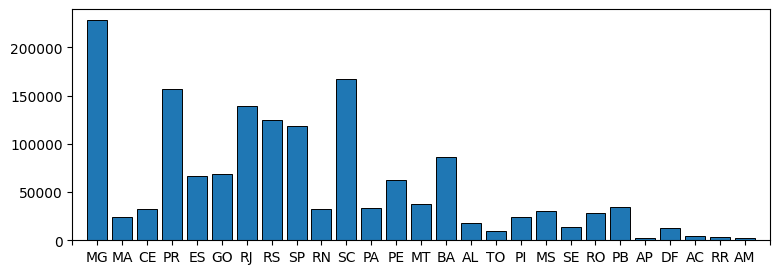

In [11]:

# Como se trata de dados sobre ACIDENTES, se consta no dataframe necessariamente é um acidente, ou seja, podemos extrair apenas realizando
# um count por uf

plot_bar(count_freq(df, 'uf')[0], count_freq(df, 'uf')[1])

        # - lista de frequência em relação aos valores únicos, a pos i vai ser o valor único em uma lista e sua freq em outra

In [12]:
# Função para pegar as horas do horário:

def get_hour(hours: str) -> str:
    # formato do horário "hh:mm:ss, ou seja, um split com ':' + [0] retorna o horário"
    return hours.split(':')[0]

In [ ]:
# fazer com fases do dia para ter uma outra visão

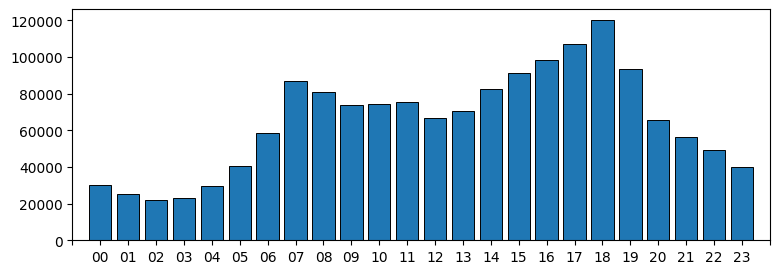

In [13]:
# Horários que mais possuem acidentes

# Problema: não separei antes nos dados, mas não é problema

# TODO: Aplicar isso sobre as funções que criamos, talvez ver lá na questão do 

series_horas = df['horario'].apply(get_hour)

horas_unicas = sorted(list(series_horas.unique()))

freq_horas = []

# aqui não tem muito o que fazer de diferente

for i in horas_unicas:

    freq_horas.append((series_horas.loc[series_horas == i]).count())


plot_bar(horas_unicas, freq_horas)

In [ ]:
# talvez junta = total, leves, médios e graves em um único gráfico

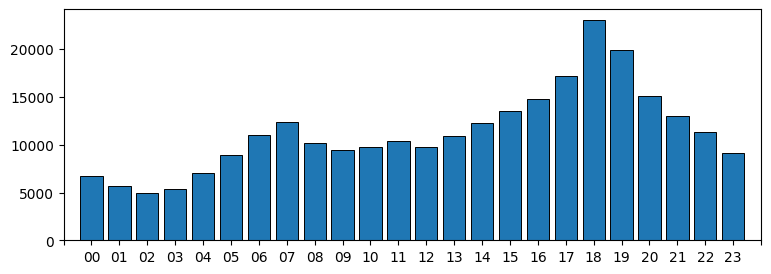

In [34]:
# Horários com os acidentes + graves

# aqui não tem muito o que fazer de diferente


# Beleza, agora, o que considerados uma acidente grave?

    # Vou aplicar uma regra de negócio aqui:

"""

Um acidente é grave é, se e somente se, atende algumas das seguintes condições:

    - Uma pessoa ferida gravemente
    - + 2 de duas pessoas feridas
    - Uma pessoa que, infelizmente, faleceu no acidente (não gosto muito)

"""

# Beleza, agora como eu misturo isso tudo de condição

series_horas = (df[((df['feridos'] > 2) | (df['mortos'] > 0) | (df['feridos_graves'] > 0))])['horario'].apply(get_hour)

horas_unicas = sorted(list(series_horas.unique()))

freq_horas = []

# aqui não tem muito o que fazer de diferente

for i in horas_unicas:

    freq_horas.append((series_horas.loc[series_horas == i]).count())


plot_bar(horas_unicas, freq_horas)

In [29]:
df.columns

Index(['data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio',
       'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia',
       'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via',
       'uso_solo', 'ano', 'pessoas', 'mortos', 'feridos_leves',
       'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'dia',
       'mes'],
      dtype='str')

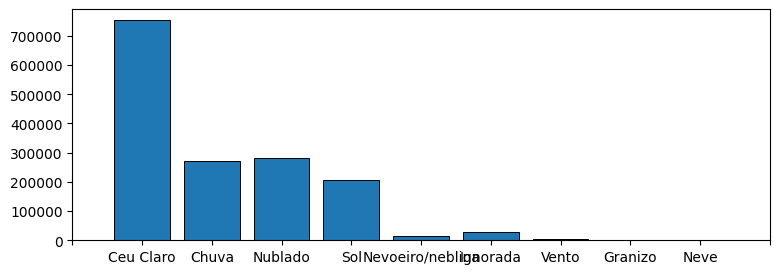

In [35]:
# Condições que mais possuem acidentes


# Como se trata de dados sobre ACIDENTES, se consta no dataframe necessariamente é um acidente, ou seja, podemos extrair apenas realizando
# um count por uf

plot_bar(count_freq(df, 'condicao_metereologica')[0], count_freq(df, 'condicao_metereologica')[1])

        # - lista de frequência em relação aos valores únicos, a pos i vai ser o valor único em uma lista e sua freq em outra

In [37]:
df.sample(2)

,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,...,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,dia,mes
1245611,2014-06-02,Segunda,22:50:00,PR,373,178.3,PONTA GROSSA,Falta de atenção,Atropelamento de pessoa,Com Vítimas Fatais,...,3,1,1,0,1,0,1,1,2,6
1186700,2014-01-25,Sábado,21:15:00,SC,101,417.1,ARARANGUA,Velocidade incompatível,Colisão com objeto fixo,Com Vítimas Feridas,...,1,0,1,0,0,0,1,1,25,1


In [ ]:
# Como o número de acidentes foi crescendo por mês/ano



In [ ]:
# Como o número de acidentes graves se portou